# Jupyter Notebook
# Lec 10: Logistic Regression

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd 
%matplotlib inline
import seaborn as sns

# Getting a feel for the data

We're going to use the `Default` data set from the ISLR book as included in their R package.  I've included a csv on the [DataSets page](../../DataSets/DataSets.md) for you to use. 

In [2]:
Default = pd.read_csv('../../DataSets/Default.csv')
Default.head()

,default,student,balance,income
0,No,No,729.526495,44361.62507
1,No,Yes,817.180407,12106.13470
2,No,No,1073.549164,31767.13895
3,No,No,529.250605,35704.49394
4,No,No,785.655883,38463.49588


In [4]:
# Here's all the entries in the "default" column
list(Default['default'].unique())

['No', 'Yes']

## Classification using Logistic Regression

Our goal is to predict `default`, a categorical variable taking as values the strings `No` and `Yes`.


For this module, we will largely use the tools from `sklearn`  for classification. One of the big perks of the `sklearn` module is that there is a great deal of uniformity in the classes. So once we have a handle on how to interact with one kind of classification tool, very minor tweaks in the code will allow for the use of a new model. In fact, many of the things we'll do today should look very similar in terms of the syntax to the linear regression lab from a few weeks ago. 

For our first try doing classification, we'll use `LogisticRegression` from the `sklearn.linear_model` module. I'm a huge fan of the `sklean` documentaiton since it includes a great deal of info on the math behind what we're doing as well as explanations on the code:
- [`sklearn` mathematical description of logistic regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
- [`LogisticRegression` class documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression)

In [5]:
from sklearn.linear_model import LogisticRegression 

Lets first predict `default` using `balance`. 
Our first job is to extract the portion of the dataframe that we want to use. 

In [6]:
X = Default[['balance']] 
Y = Default['default']

In [7]:
print(X.shape)
print(Y.shape)

(10000, 1)
(10000,)


Once we have our data, we create an instance of the model class we want, in this case `LogisticRegression`, and fit the model to the data. Note the `random_state=0` code ensures that rerunning the following box will return the same answer every time. 

In [8]:
clf = LogisticRegression(random_state=0)
clf.fit(X,Y)


LogisticRegression(random_state=0)

One thing that is helpful for later is the `.classes_` variable which stores the possible values of $Y$ being predicted. Take note of the order of these things, it will matter later!

In [9]:
clf.classes_

array(['No', 'Yes'], dtype=object)

Great, that was easy! Once we've fit the model, the main task is to understand how to extract information from it. 

&#9989; **<font color=red>Do this:</font>** Extract the coefficients and intercept from the trained model.  
- What is the equation, in terms of the variables used, that you are modeling?
- Be specific about what probability you are modeling! 

*(Hint: You might need to take a look at the documentation to figure out how get the coefficients and intercepts, but you should notice that `sklearn` has a pattern as to how it does this.)*

In [10]:
# Your code here

In [11]:
##ANSWER##
print(clf.coef_)
print(clf.intercept_)

[[0.00549892]]
[-10.65132824]


##ANSWER##
To get the equation, they'll have to look back at either the slides or Sec 4.3.4. There we get that 

$$
p(X) = \frac{\exp(\beta_0 + \beta_1 X_1)}{1+\exp(\beta_0 + \beta_1 X_1 )}
$$

so in this case the equation is 

$$
p(X) = \frac{\exp(-0.0055 -10.6513 \cdot \texttt{balance})}{1+\exp(-0.0055 -10.6513 \cdot \texttt{balance})}
$$

Note that $p(X) = Pr(Y = \texttt{no})$ because that was the first entry in `clf.classes_`

While it's good to know what equation we're modeling with, the big perk here is that your `sklearn` class will evaluate the data points of your model for you. Yay!

&#9989; **<font color=red>Do this:</font>** Use the `predict_proba` function to determine the probabilities $Pr(Y = \texttt{Down} \mid X)$ for the data set. What shape is the output matrix? Why that shape? What do the columns represent?

In [12]:
# Your code here

In [13]:
##ANSWER##

# Checking up on the order of classes 

clf.classes_

array(['No', 'Yes'], dtype=object)

In [15]:
##ANSWER## 
# Predicting probabilities. The columns are aligned to the order of classes, so the
# first column is the probability of No, the second is the probability of Yes.
clf.predict_proba(X)

array([[9.98694319e-01, 1.30568146e-03],
       [9.97887402e-01, 2.11259754e-03],
       [9.91405252e-01, 8.59474814e-03],
       ...,
       [9.97533484e-01, 2.46651596e-03],
       [8.83240365e-01, 1.16759635e-01],
       [9.99928552e-01, 7.14476480e-05]])

Of course this gives us the probability of each each label for a given data, but we really would like to have the prediction itself. 


&#9989; **<font color=red>Do this:</font>** Use the `predict` function to determine the predictions for each input data point in the original $X$ matrix and store the output as `Yhat`. How many predictions are different than the actual `Direction` value? Whats the percent error for the model?

In [16]:
# Your code here

In [17]:
##ANSWER##
Yhat = clf.predict(X)
Yhat

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [24]:
##ANSWER##

# Last time they did this with the accuracy score 
from sklearn.metrics import accuracy_score
acc = accuracy_score(Y,Yhat)
error_perc = (1-acc)*100
print(f"The error is {round(error_perc,2)}%")

The error is 2.75%



&#9989; **<font color=red>Do this:</font>** An even easier way of figuring out the error rate is through the score. What does the output of `clf.score(X,Y)` mean and how is it related to the number you determined above?

In [25]:
# Your code here

In [27]:
##ANSWER##
# Another way to get the answer is to just use the score function which gives the percent correct.
print('Score:', clf.score(X,Y))
print('1-Score is error:', round(1-clf.score(X,Y),4))

Score: 0.9725
1-Score is error: 0.0275


**Confusion matrix**

As we saw in class, the percent error is a rather limited way of evaluating the classification model. Luckily `sklearn` provides commands for computing the confusion matrix for a given model easily. The `confusion_matrix` command computes the confusion matrix, and `ConfusionMatrixDisplay` gives a nice visual representation. 

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [29]:
# This code gives the confusion matrix, assuming you stored the predicted values as `Yhat`.
C = confusion_matrix(Y,Yhat)

C

array([[9625,   42],
       [ 233,  100]])

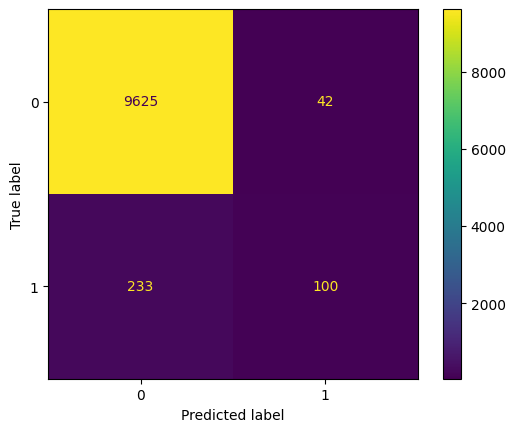

In [30]:
# This code gives a visual representation 
ConfusionMatrixDisplay(C).plot()



&#9989; **<font color=red>Q:</font>** The makers of `sklearn` made a PARTICULARY strange choice when it comes to the confusion matrix representation.  What is different about the `sklearn` confusion matrix from how we saw it in class?

*Your answer here*

##ANSWER## 

*They put true label on the rows and predicted on the columns. We did the transpose in class. I've seen it as the transpose literally everywhere but in this code. Yarg.*



-----
### Congratulations, we're done!
Written by Dr. Liz Munch, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.

In [31]:
##ANSWER##
#This cell runs the converter which removes ANSWER fields, renames the notebook and cleans out output fields. 

from jupyterinstruct import InstructorNotebook
import os
this_notebook = os.path.basename(globals()['__vsc_ipynb_file__'])

studentnotebook = InstructorNotebook.makestudent(this_notebook)

InstructorNotebook.validate(studentnotebook)


<IPython.core.display.Javascript object>

Myfilename CMSE381-Lec10-LogisticRegression-INSTRUCTOR.ipynb


CMSE381-Lec10_LogisticRegression.ipynb


Validating Notebook ./CMSE381-Lec10_LogisticRegression.ipynb


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


0